In [89]:
from symbol import continue_stmt

import numpy as np
import pandas as pd
import datetime as dt
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [90]:
df = yf.download("AAPL",start="2016-01-01",end="2026-01-01",auto_adjust=False,multi_level_index=False)

[*********************100%***********************]  1 of 1 completed


In [94]:
df_weekly = df['Adj Close'].resample('W').last()

df_weekly = pd.DataFrame(df_weekly)
df_weekly['returns'] = df_weekly['Adj Close'].pct_change()

df_weekly.dropna(inplace=True)
df = df_weekly.copy()
df

,Adj Close,returns
Date,,
2016-01-24,22.845684,0.044168
2016-01-31,21.926626,-0.040229
2016-02-07,21.293694,-0.028866
2016-02-14,21.286896,-0.000319
2016-02-21,21.751181,0.021811
...,...,...
2025-12-07,278.519379,-0.000251
2025-12-14,278.019867,-0.001793
2025-12-21,273.414185,-0.016566


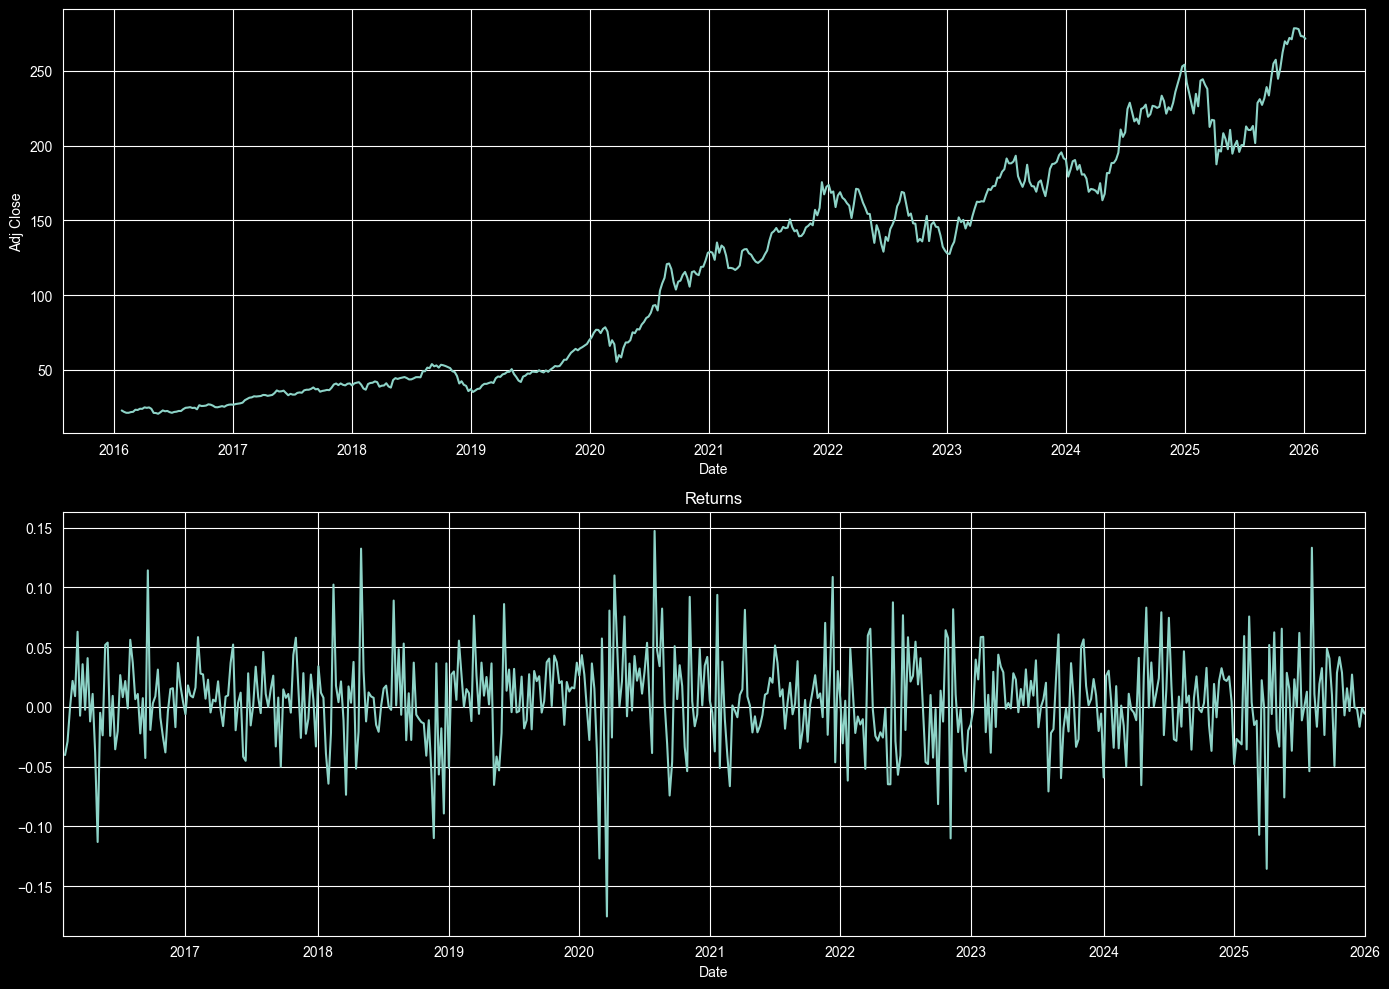

In [97]:
# Creating Returns to make data stationarity and removing trend,season and pattern

df['returns'] = df['Adj Close'].pct_change()
# Plotting Price and Daily Returns

# Plotting close price
fig,(ax1,ax2) = plt.subplots(2,1,figsize=(14,10))
sns.lineplot(df['Adj Close'], ax=ax1)
plt.title('Closing Prices')

# Plotting daily returns
df['returns'].plot(ax=ax2)
plt.title('Returns')

plt.tight_layout()
plt.show()

# Dropping columns and NaNs
df = df[['returns']]
df.dropna(inplace=True)

In [98]:
# Adfuller test for checking P value using it is stationary
from statsmodels.tsa.stattools import adfuller
result = adfuller(df['returns'])

print("p-value:{:.2e}".format(result[1]))

p-value:0.00e+00


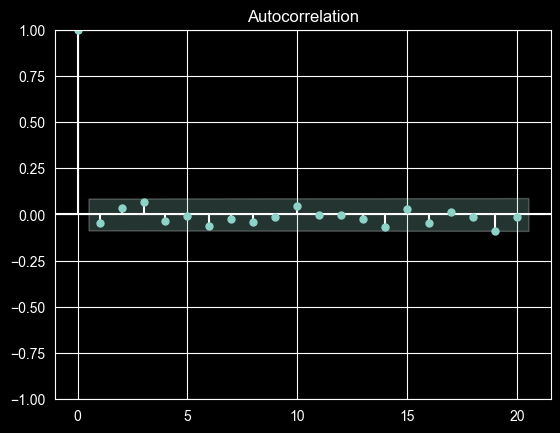

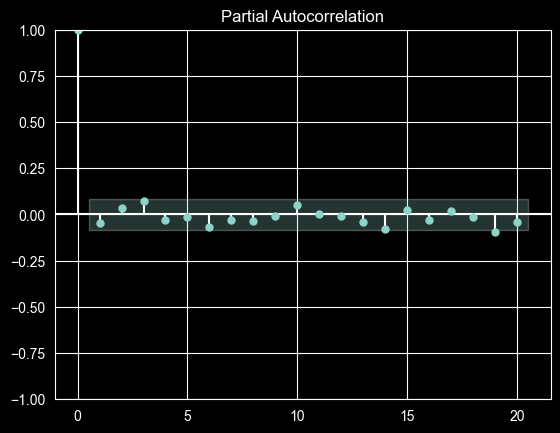

In [99]:
# plotting ACF AND PACF
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

plot_acf(df['returns'], lags=20)
plt.title('Autocorrelation')


plot_pacf(df['returns'], lags=20)
plt.title('Partial Autocorrelation')

plt.show()

# AR model

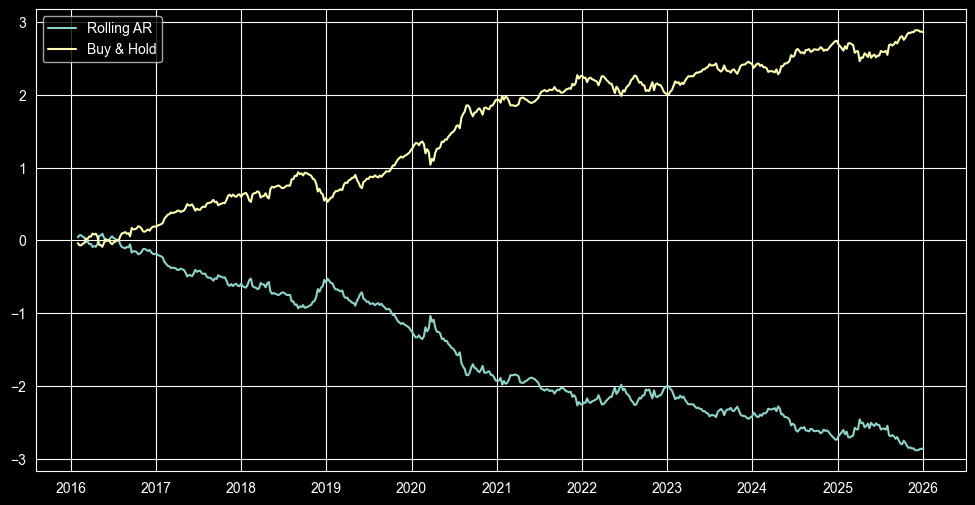

In [100]:
from statsmodels.tsa.arima_model import ARIMA
window = 50
df['forecast'] = np.nan
for i in range(window,len(df)):

    train = df['returns'][i-window:i]

    try:
        model = ARIMA(train, order=(1,0,0)).fit()
        forecast = model.forecast(steps=1).iloc[0]

        df.iloc[i,df.columns.get_loc('forecast')] = forecast
    except:
            continue

# Strategy
df['signal'] = np.where(df['forecast'] > 0, 1, -1)
df['strategy'] = df['signal'] * df['returns']
df['cum_strategy'] = df['strategy'].cumsum()
df['buy_hold'] = df['returns'].cumsum()

# Plotting
plt.figure(figsize=(12,6))
plt.plot(df['cum_strategy'], label='Rolling AR')
plt.plot(df['buy_hold'], label='Buy & Hold')
plt.legend()
plt.show()